# 06 Modeling — Predicting Future Realized Volatility

This notebook trains our first predictive model. Following the focus set in notebook 05, the target is **future realized volatility**: given what we know about an asset today, predict how volatile it will be over the next 21 trading days (about one month).

Why volatility and not returns? Daily returns are close to unpredictable noise, but volatility *clusters* — calm markets tend to stay calm and turbulent markets stay turbulent — so a model can actually learn something, which makes it a much better setting to practice hyperparameter tuning.

The model is **Ridge regression**, trained as one pooled model on all 21 tickers together. Each row is one (date, ticker) observation, and ticker-specific behavior comes through the features (each ticker carries its own rolling volatility, momentum, and sector dummies), so the pooled model does not collapse to an "average" asset.

Ridge has a single hyperparameter, `alpha` (regularization strength), which we tune with time-series cross-validation.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Paths

In [2]:
INTEGRATED_PATH = Path("../data/processed/integrated")
MODELING_PATH = Path("../data/processed/modeling")

MODELING_PATH.mkdir(parents=True, exist_ok=True)

# Load Integrated Data

We start from the modeling base dataset created in notebook 04 (long format: one row per date per ticker).

In [3]:
df = pd.read_csv(
    INTEGRATED_PATH / "modeling_base_dataset.csv",
    parse_dates=["Date"]
)

df = df.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(df.shape)
df.head()

(42189, 11)


,Date,ticker,adjusted_close,daily_return,risk_free_rate_pct,risk_free_rate_decimal,cpi_index,cpi_pct_change,company_name,gics_sector,asset_type
0,2018-01-03,AAPL,40.260067,-0.000174,1.41,0.0141,248.859,0.0,Apple Inc.,Information Technology,Stock
1,2018-01-04,AAPL,40.447075,0.004645,1.41,0.0141,248.859,0.0,Apple Inc.,Information Technology,Stock
2,2018-01-05,AAPL,40.907566,0.011385,1.39,0.0139,248.859,0.0,Apple Inc.,Information Technology,Stock
3,2018-01-08,AAPL,40.755634,-0.003714,1.45,0.0145,248.859,0.0,Apple Inc.,Information Technology,Stock
4,2018-01-09,AAPL,40.750969,-0.000114,1.44,0.0144,248.859,0.0,Apple Inc.,Information Technology,Stock


# Build Features

All rolling features are computed **within each ticker** using `groupby("ticker")`, so one asset's history never bleeds into another's. Every feature only uses information available up to and including day *t* — no peeking at the future.

These mirror the features explored in notebook 05:
- Rolling mean returns (5d, 21d, 63d) — recent momentum
- Rolling volatility (5d, 21d, 63d) — recent risk level
- Price relative to its moving average (21d, 63d) — trend position
- Macro context: risk-free rate and monthly CPI change (from FRED)

In [4]:
g = df.groupby("ticker")

for window in [5, 21, 63]:
    df[f"ret_mean_{window}d"] = g["daily_return"].transform(lambda s: s.rolling(window).mean())
    df[f"vol_{window}d"] = g["daily_return"].transform(lambda s: s.rolling(window).std())

for window in [21, 63]:
    moving_average = g["adjusted_close"].transform(lambda s: s.rolling(window).mean())
    df[f"price_to_ma_{window}d"] = df["adjusted_close"] / moving_average

# Build Target — Forward 21-Day Realized Volatility

The target for a row on day *t* is the standard deviation of that ticker's daily returns over days *t+1* to *t+21*. We compute a 21-day rolling std (which at row *t* covers days *t-20 … t*) and then shift it back 21 rows within each ticker, so the value that lands on day *t* covers exactly the next 21 trading days.

In [5]:
df["fwd_vol_21d"] = (
    df.groupby("ticker")["daily_return"]
    .transform(lambda s: s.rolling(21).std().shift(-21))
)

# Encode Categorical Metadata

One-hot encode sector and asset type. This is how the pooled model tells asset classes apart — bonds, gold, and tech stocks each get their own baseline volatility level.

In [6]:
df = pd.get_dummies(df, columns=["gics_sector", "asset_type"], drop_first=False)

dummy_columns = [c for c in df.columns if c.startswith(("gics_sector_", "asset_type_"))]
print(f"{len(dummy_columns)} dummy columns created")

18 dummy columns created


# Assemble Model Dataset

Drop the warm-up rows (first 63 days per ticker have incomplete rolling features) and the last 21 days per ticker (no future window to compute the target from).

In [7]:
FEATURE_COLUMNS = (
    ["ret_mean_5d", "ret_mean_21d", "ret_mean_63d",
     "vol_5d", "vol_21d", "vol_63d",
     "price_to_ma_21d", "price_to_ma_63d",
     "risk_free_rate_decimal", "cpi_pct_change"]
    + dummy_columns
)
TARGET_COLUMN = "fwd_vol_21d"

model_df = df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).copy()

print("Rows before dropna:", len(df))
print("Rows after dropna:", len(model_df))
print("Features:", len(FEATURE_COLUMNS))

Rows before dropna: 42189
Rows after dropna: 40446
Features: 28


# Train/Test Split — By Date, Not By Row

We split chronologically: everything before 2024 is training data, 2024 onward is the held-out test set. A random shuffled split would leak the future into training (the model would see 2025 market conditions while being "tested" on 2024) and give fake-good scores.

All 21 tickers appear on both sides of the split — the split is on **time**, not on assets.

In [8]:
SPLIT_DATE = "2024-01-01"

# TimeSeriesSplit later assumes rows are in chronological order, so sort by Date
model_df = model_df.sort_values("Date").reset_index(drop=True)

train_df = model_df[model_df["Date"] < SPLIT_DATE]
test_df = model_df[model_df["Date"] >= SPLIT_DATE]

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

print(f"Train: {X_train.shape[0]} rows, {train_df['Date'].min().date()} to {train_df['Date'].max().date()}")
print(f"Test:  {X_test.shape[0]} rows, {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

Train: 30366 rows, 2018-04-04 to 2023-12-29
Test:  10080 rows, 2024-01-02 to 2025-11-28


# Baseline — Persistence

Before training anything, we need a baseline to beat. The simplest credible forecast of future volatility is **current volatility**: predict that the next 21 days will look like the last 21 days. Any model that can't beat this isn't adding value.

In [9]:
baseline_pred = test_df["vol_21d"]

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"Persistence baseline — R2: {baseline_r2:.4f}, MAE: {baseline_mae:.6f}")

Persistence baseline — R2: 0.0035, MAE: 0.004614


# Ridge Regression + Hyperparameter Tuning

The pipeline scales features first (`StandardScaler`) because Ridge's penalty is scale-sensitive — without scaling, features with big numeric ranges would be unfairly penalized.

Ridge's one hyperparameter is `alpha`:
- **alpha → 0**: no regularization, plain linear regression (risk of overfitting)
- **alpha → large**: coefficients shrink toward zero, the model gets simpler (risk of underfitting)

We search alpha over 8 orders of magnitude using `GridSearchCV` with `TimeSeriesSplit`, which always validates on data **after** the fold it trained on — the time-series version of cross-validation.

In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {"ridge__alpha": np.logspace(-3, 5, 17)}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_["ridge__alpha"])

Best alpha: 31622.776601683792


# Validation Curve — What Tuning Actually Does

This plot is the whole point of hyperparameter tuning: validation error as a function of alpha. Flat on the left (regularization too weak to matter), rising on the right (regularization so strong the model underfits), with the sweet spot in between.

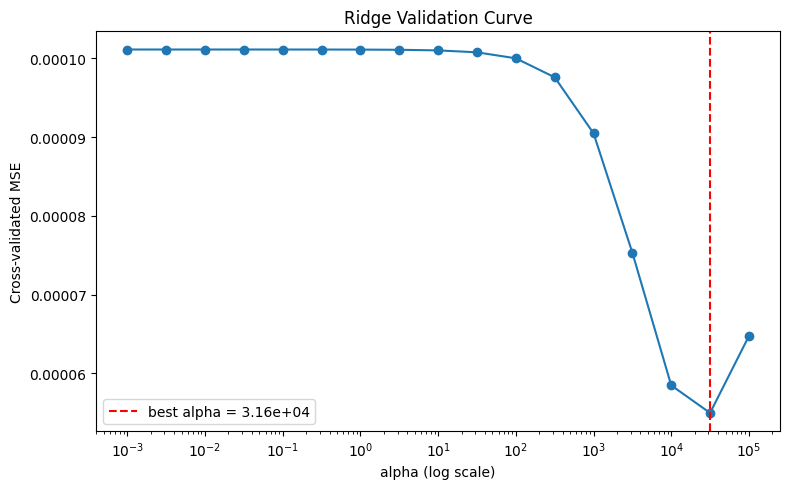

In [11]:
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas = cv_results["param_ridge__alpha"].astype(float)
cv_mse = -cv_results["mean_test_score"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, cv_mse, marker="o")
ax.axvline(grid_search.best_params_["ridge__alpha"], color="red", linestyle="--",
           label=f"best alpha = {grid_search.best_params_['ridge__alpha']:.3g}")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Cross-validated MSE")
ax.set_title("Ridge Validation Curve")
ax.legend()
plt.tight_layout()
plt.show()

# Evaluate on the Held-Out Test Set

The tuned model now sees the 2024+ data for the first time. We compare against the persistence baseline — beating it means the model's extra features (momentum, longer volatility windows, macro, sector) add real predictive value.

In [12]:
y_pred = grid_search.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred)
ridge_mae = mean_absolute_error(y_test, y_pred)

print(f"Persistence baseline — R2: {baseline_r2:.4f}, MAE: {baseline_mae:.6f}")
print(f"Tuned Ridge         — R2: {ridge_r2:.4f}, MAE: {ridge_mae:.6f}")

Persistence baseline — R2: 0.0035, MAE: 0.004614
Tuned Ridge         — R2: 0.3653, MAE: 0.003808


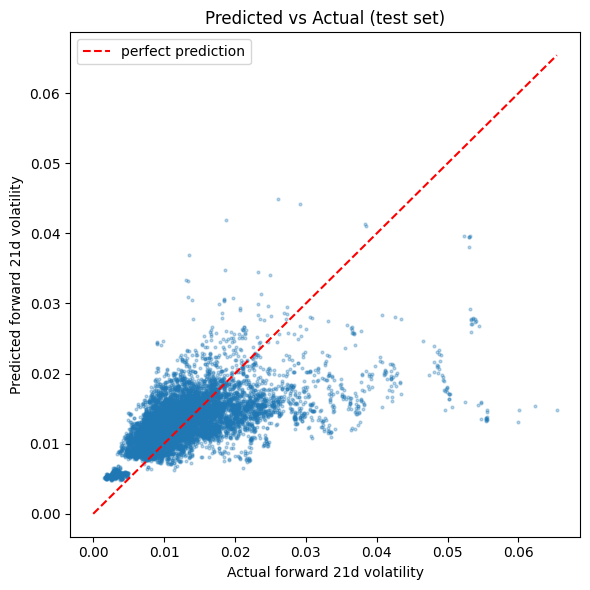

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=4, alpha=0.3)
limit = max(y_test.max(), y_pred.max())
ax.plot([0, limit], [0, limit], color="red", linestyle="--", label="perfect prediction")
ax.set_xlabel("Actual forward 21d volatility")
ax.set_ylabel("Predicted forward 21d volatility")
ax.set_title("Predicted vs Actual (test set)")
ax.legend()
plt.tight_layout()
plt.show()

# Which Features Matter?

Because features were standardized, coefficient magnitudes are directly comparable. Expect the recent volatility features (`vol_21d`, `vol_63d`) to dominate — volatility clustering is the main signal.

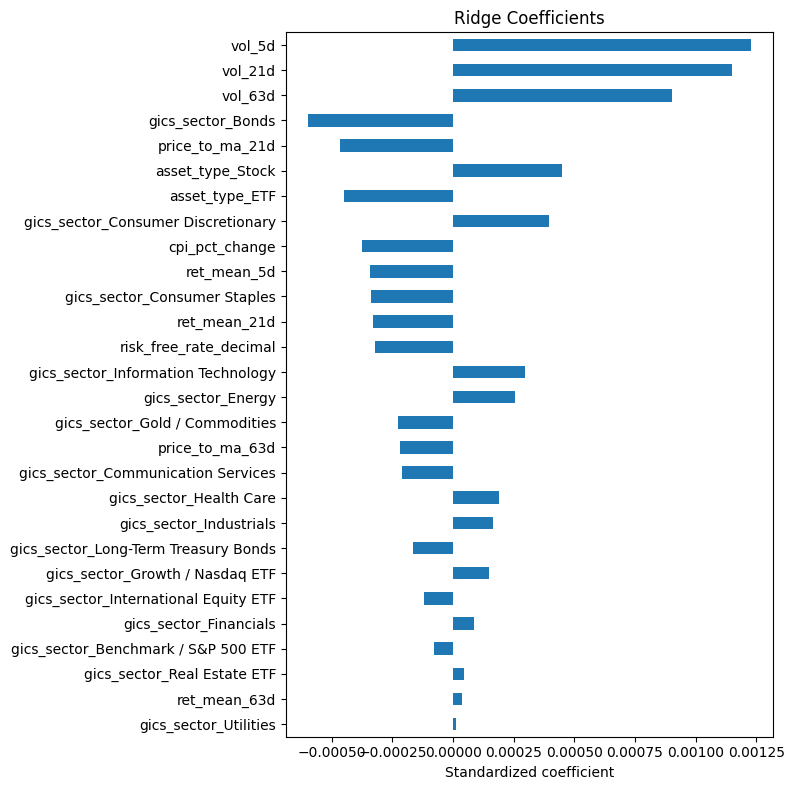

In [14]:
best_ridge = grid_search.best_estimator_.named_steps["ridge"]

coefficients = (
    pd.Series(best_ridge.coef_, index=FEATURE_COLUMNS)
    .sort_values(key=np.abs)
)

fig, ax = plt.subplots(figsize=(8, 8))
coefficients.plot.barh(ax=ax)
ax.set_xlabel("Standardized coefficient")
ax.set_title("Ridge Coefficients")
plt.tight_layout()
plt.show()

# Sanity Check — Does the Pooled Model Distinguish Tickers?

One pooled model, but per-ticker inputs. If it were just predicting "average volatility," every ticker's predictions would look the same. Instead, quiet assets (AGG) should sit near zero and volatile ones (AAPL, AMZN) much higher.

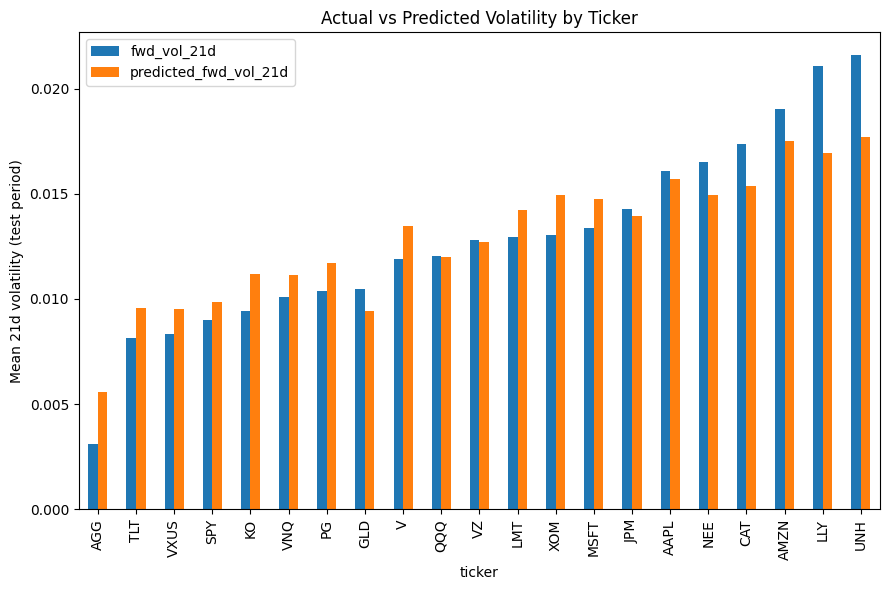

In [15]:
test_results = test_df.copy()
test_results["predicted_fwd_vol_21d"] = y_pred

per_ticker = (
    test_results.groupby("ticker")[[TARGET_COLUMN, "predicted_fwd_vol_21d"]]
    .mean()
    .sort_values(TARGET_COLUMN)
)

fig, ax = plt.subplots(figsize=(9, 6))
per_ticker.plot.bar(ax=ax)
ax.set_ylabel("Mean 21d volatility (test period)")
ax.set_title("Actual vs Predicted Volatility by Ticker")
plt.tight_layout()
plt.show()

# Save Test Predictions

In [16]:
output_columns = ["Date", "ticker", TARGET_COLUMN, "predicted_fwd_vol_21d"]

test_results[output_columns].to_csv(
    MODELING_PATH / "ridge_volatility_test_predictions.csv",
    index=False
)

print("Saved:", MODELING_PATH / "ridge_volatility_test_predictions.csv")

Saved: ../data/processed/modeling/ridge_volatility_test_predictions.csv


# Final Summary

In this notebook we:

- Built leakage-safe features per ticker (rolling returns, rolling volatility, price-to-moving-average, macro context) from the integrated long-format dataset
- Defined the target as forward 21-day realized volatility
- Split train/test **by date** (train < 2024, test ≥ 2024) to avoid look-ahead bias
- Established a persistence baseline (future volatility = current volatility)
- Trained one pooled Ridge regression across all 21 tickers and tuned `alpha` with `GridSearchCV` + `TimeSeriesSplit`
- Verified the pooled model distinguishes quiet assets from volatile ones